In [1]:
from src.data.loader import load_multiple_intervals
import yfinance as yf
from datetime import date, datetime
from dateutil.relativedelta import relativedelta

import pandas as pd

In [2]:
intervals = ["1m", "5m", "15m", "30m", "60m", "1d"]

tickets = {
    "BTC-USD": "BTC"
}

datasets = load_multiple_intervals(
    ticker_names=tickets,
    intervals=intervals,
    start_date="2014-01-01",
    end_date="2026-04-14",
    price_type=["High", "Low", "Close", "Volume"],
)

df_1m = datasets["1m"]
df_5m = datasets["5m"]
df_15m = datasets["15m"]
df_30m = datasets["30m"]
df_60m = datasets["60m"]
df_1d = datasets["1d"]

1m
2026-04-09 00:00:00 2026-04-15 00:00:00
{'BTC-USD': 'BTC'} 2014-01-01 2026-04-09 00:00:00
{'BTC-USD': 'BTC'} 2026-04-14 2026-04-15 00:00:00
[INFO] Data successfully loaded: 2026-04-09 to 2026-04-15.
--------------------------------------------------
5m
2026-02-15 00:00:00 2026-04-15 00:00:00
{'BTC-USD': 'BTC'} 2014-01-01 2026-02-15 00:00:00
{'BTC-USD': 'BTC'} 2026-04-14 2026-04-15 00:00:00
[INFO] Data successfully loaded: 2026-02-15 to 2026-04-15.
--------------------------------------------------
15m
2026-02-15 00:00:00 2026-04-15 00:00:00
{'BTC-USD': 'BTC'} 2014-01-01 2026-02-15 00:00:00
{'BTC-USD': 'BTC'} 2026-04-14 2026-04-15 00:00:00
[INFO] Data successfully loaded: 2026-02-15 to 2026-04-15.
--------------------------------------------------
30m
2026-02-15 00:00:00 2026-04-15 00:00:00
{'BTC-USD': 'BTC'} 2014-01-01 2026-02-15 00:00:00
{'BTC-USD': 'BTC'} 2026-04-14 2026-04-15 00:00:00
[INFO] Data successfully loaded: 2026-02-15 to 2026-04-15.
-------------------------------------

In [3]:
df_15m

,Datetime,BTC_Close,BTC_High,BTC_Low,BTC_Volume
0,2026-02-15 00:00:00+00:00,69676.23,69812.29,69676.23,43352064
1,2026-02-15 00:15:00+00:00,69651.00,69726.54,69637.79,70610944
2,2026-02-15 00:30:00+00:00,69627.08,69724.38,69622.46,21315584
3,2026-02-15 00:45:00+00:00,69724.40,69752.25,69591.52,62230528
4,2026-02-15 01:00:00+00:00,69835.53,69855.31,69724.06,94781440
...,...,...,...,...,...
5659,2026-04-14 22:45:00+00:00,74067.36,74155.93,74005.47,0
5660,2026-04-14 23:00:00+00:00,74144.03,74198.23,74046.18,0
5661,2026-04-14 23:15:00+00:00,74152.00,74244.01,74089.61,0
5662,2026-04-14 23:30:00+00:00,74216.09,74250.12,74081.59,0


In [4]:
import matplotlib.pyplot as plt

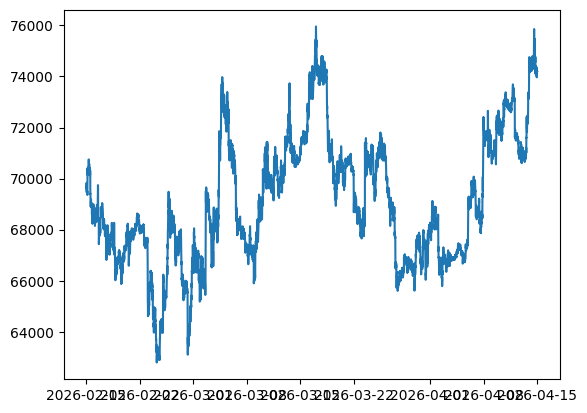

In [5]:
plt.plot(df_15m['Datetime'], df_15m['BTC_Close'])

In [ ]:
from sklearn.model_selection import train_test_split

In [40]:
df_15m['BTC_Close_rolling'] = df_15m['BTC_Close'].shift(-10)

In [41]:
df_15m = df_15m.dropna()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(df_15m.drop('BTC_Close_rolling', axis=1), df_15m['BTC_Close_rolling'], shuffle=False)

In [59]:
from src.models.elastic_net_model import ElasticNetModel

model = ElasticNetModel()

model.fit(X_train.drop('Datetime', axis=1), y_train)
pred_ElasticNet = model.predict(X_test.drop('Datetime', axis=1))

model.evaluate(X_test.drop('Datetime', axis=1), y_test)

/Users/mac/Diploma/env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.441e+08, tolerance: 2.460e+06
  model = cd_fast.enet_coordinate_descent(


{'model': 'ElasticNet',
 'MAE': 337.57329359389485,
 'RMSE': 491.473034292952,
 'R2': 0.9624554095835102}

In [60]:
from src.models.random_forest_model import RandomForestModel

model = RandomForestModel()

model.fit(X_train.drop('Datetime', axis=1), y_train)
pred_RandomForest = model.predict(X_test.drop('Datetime', axis=1))

model.evaluate(X_test.drop('Datetime', axis=1), y_test)

{'model': 'RandomForestRegressor',
 'MAE': 392.8803193698027,
 'RMSE': 542.5221259509757,
 'R2': 0.9542508644760404}

In [61]:
from src.models.gradient_boosting_model import GradientBoostingModel

model = GradientBoostingModel()

model.fit(X_train.drop('Datetime', axis=1), y_train)
pred_Gradientoosting = model.predict(X_test.drop('Datetime', axis=1))

model.evaluate(X_test.drop('Datetime', axis=1), y_test)

{'model': 'GradientBoostingRegressor',
 'MAE': 351.5000585687347,
 'RMSE': 501.9684892291577,
 'R2': 0.9608347509057308}

In [58]:
from src.models.lstm_model import LSTMModel

model = LSTMModel(
    input_shape=(X_train.shape[0], X_train.shape[1]),
    lstm_units=64,
    epochs=20,
    batch_size=32
    )

model.fit(X_train.drop('Datetime', axis=1), y_train)
pred_LSTM = model.predict(X_test.drop('Datetime', axis=1))

Epoch 1/20


/Users/mac/Diploma/env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 4), dtype=float32) with name 'keras_tensor' and path ''. Expected shape (None, 4236, 5), but input has incompatible shape (None, 4)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 4), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

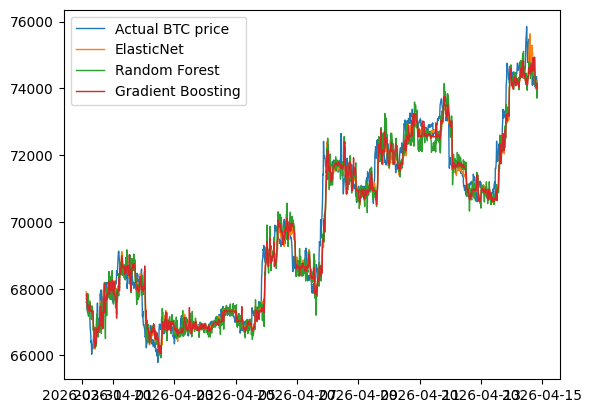

In [55]:
plt.plot(X_test['Datetime'], y_test, label='Actual BTC price', linewidth=1)
plt.plot(X_test['Datetime'], pred_ElasticNet, label='ElasticNet', linewidth=1)
plt.plot(X_test['Datetime'], pred_RandomForest, label='Random Forest', linewidth=1)
plt.plot(X_test['Datetime'], pred_Gradientoosting, label='Gradient Boosting', linewidth=1)

plt.legend()